# Market Basket Analysis — Data Science & Mining Project

**Algorithm:** Apriori for Association Rule Mining  
**Dataset:** Sample Grocery Store Transactions  
**Application:** Market Basket Analyzer (PWA)

This notebook demonstrates the complete data science pipeline:
1. Data Collection & Loading
2. Data Preprocessing & Cleaning
3. Exploratory Data Analysis (EDA)
4. Transaction Encoding (One-Hot)
5. Frequent Itemset Mining (Apriori Algorithm)
6. Association Rule Generation
7. Visualization of Results
8. Model Evaluation & Interpretation
9. Practical Recommendation Demo
10. Conclusions

## Step 0: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from collections import Counter
from matplotlib.patches import Patch
import warnings

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
sns.set_palette('viridis')
%matplotlib inline

print('Libraries loaded successfully!')

Libraries loaded successfully!


## Step 1: Data Collection & Loading

We simulate a realistic grocery store transaction dataset. In our web app, this data comes from user-uploaded CSV files or manual entries stored in MongoDB.

In [3]:
raw_transactions = [
    ["milk", "bread", "eggs"],
    ["milk", "bread", "butter"],
    ["bread", "butter", "cheese"],
    ["milk", "eggs", "cheese"],
    ["sugar", "coffee"],
    ["sugar", "coffee", "milk", "biscuits"],
    ["coffee", "bread", "butter"],
    ["bread", "eggs", "milk", "apple"],
    ["apple", "banana", "orange"],
    ["milk", "bread", "apple"],
    ["coffee", "sugar", "biscuits"],
    ["milk", "diapers", "baby wipes"],
    ["bread", "diapers", "baby wipes", "milk"],
    ["beer", "chips", "salsa"],
    ["beer", "chips"],
    ["pizza", "beer", "chips"],
    ["milk", "bread", "salsa"],
    ["coffee", "sugar", "milk", "cookies"],
    ["milk", "cereals"],
    ["cereals", "milk", "banana"],
    ["eggs", "bacon", "bread"],
    ["bacon", "eggs", "coffee"],
    ["milk", "bread", "butter", "eggs", "coffee"],
    ["pizza", "soda"],
    ["pizza", "soda", "chips"],
    ["milk", "bread", "butter", "jam"],
    ["tea", "sugar", "biscuits"],
    ["bread", "cheese", "ham"],
    ["milk", "cereals", "banana", "yogurt"],
    ["coffee", "milk", "sugar", "cream"],
    ["eggs", "bread", "milk", "juice"],
    ["beer", "chips", "popcorn"],
    ["pizza", "beer", "soda", "chips"],
    ["milk", "bread", "eggs", "cheese"],
    ["butter", "bread", "jam", "milk"],
    ["coffee", "sugar", "cream"],
    ["diapers", "baby wipes", "milk", "bread"],
    ["apple", "banana", "yogurt"],
    ["bacon", "eggs", "bread", "butter"],
    ["milk", "bread", "coffee", "sugar"],
]

df_transactions = pd.DataFrame({
    "Transaction_ID": range(1, len(raw_transactions) + 1),
    "Items": raw_transactions
})

print(f"Total Transactions: {len(raw_transactions)}")
print(f"Sample Transaction: {raw_transactions[0]}")
df_transactions.head(10)

Total Transactions: 40
Sample Transaction: ['milk', 'bread', 'eggs']


,Transaction_ID,Items
0,1,"[milk, bread, eggs]"
1,2,"[milk, bread, butter]"
2,3,"[bread, butter, cheese]"
3,4,"[milk, eggs, cheese]"
4,5,"[sugar, coffee]"
5,6,"[sugar, coffee, milk, biscuits]"
6,7,"[coffee, bread, butter]"
7,8,"[bread, eggs, milk, apple]"
8,9,"[apple, banana, orange]"
9,10,"[milk, bread, apple]"


## Step 2: Data Preprocessing & Cleaning

- **Lowercase normalization** — ensures 'Milk' and 'milk' are treated as the same item
- **Deduplication** — removes repeated items within a single transaction
- **Basic statistics** — item counts, basket sizes

In [4]:
cleaned_transactions = []
for transaction in raw_transactions:
    cleaned = [item.strip().lower() for item in transaction]
    cleaned = list(set(cleaned))
    cleaned_transactions.append(cleaned)

all_items = [item for t in cleaned_transactions for item in t]
unique_items = set(all_items)

print(f"Total item occurrences    : {len(all_items)}")
print(f"Unique items              : {len(unique_items)}")
print(f"Avg items per transaction : {np.mean([len(t) for t in cleaned_transactions]):.2f}")
print(f"Min basket size           : {min(len(t) for t in cleaned_transactions)}")
print(f"Max basket size           : {max(len(t) for t in cleaned_transactions)}")
print(f"\nAll unique items: {sorted(unique_items)}")

Total item occurrences    : 132
Unique items              : 28
Avg items per transaction : 3.30
Min basket size           : 2
Max basket size           : 5

All unique items: ['apple', 'baby wipes', 'bacon', 'banana', 'beer', 'biscuits', 'bread', 'butter', 'cereals', 'cheese', 'chips', 'coffee', 'cookies', 'cream', 'diapers', 'eggs', 'ham', 'jam', 'juice', 'milk', 'orange', 'pizza', 'popcorn', 'salsa', 'soda', 'sugar', 'tea', 'yogurt']


## Step 3: Exploratory Data Analysis (EDA)

In [5]:
item_counts = Counter(all_items)
item_freq_df = pd.DataFrame(item_counts.most_common(), columns=["Item", "Frequency"])
item_freq_df["Support (%)"] = (item_freq_df["Frequency"] / len(cleaned_transactions) * 100).round(2)

print("Top 10 Most Frequent Items:")
item_freq_df.head(10)

Top 10 Most Frequent Items:


,Item,Frequency,Support (%)
0,milk,21,52.5
1,bread,18,45.0
2,coffee,10,25.0
3,eggs,9,22.5
4,sugar,8,20.0
5,butter,7,17.5
6,chips,6,15.0
7,beer,5,12.5
8,cheese,4,10.0
9,apple,4,10.0


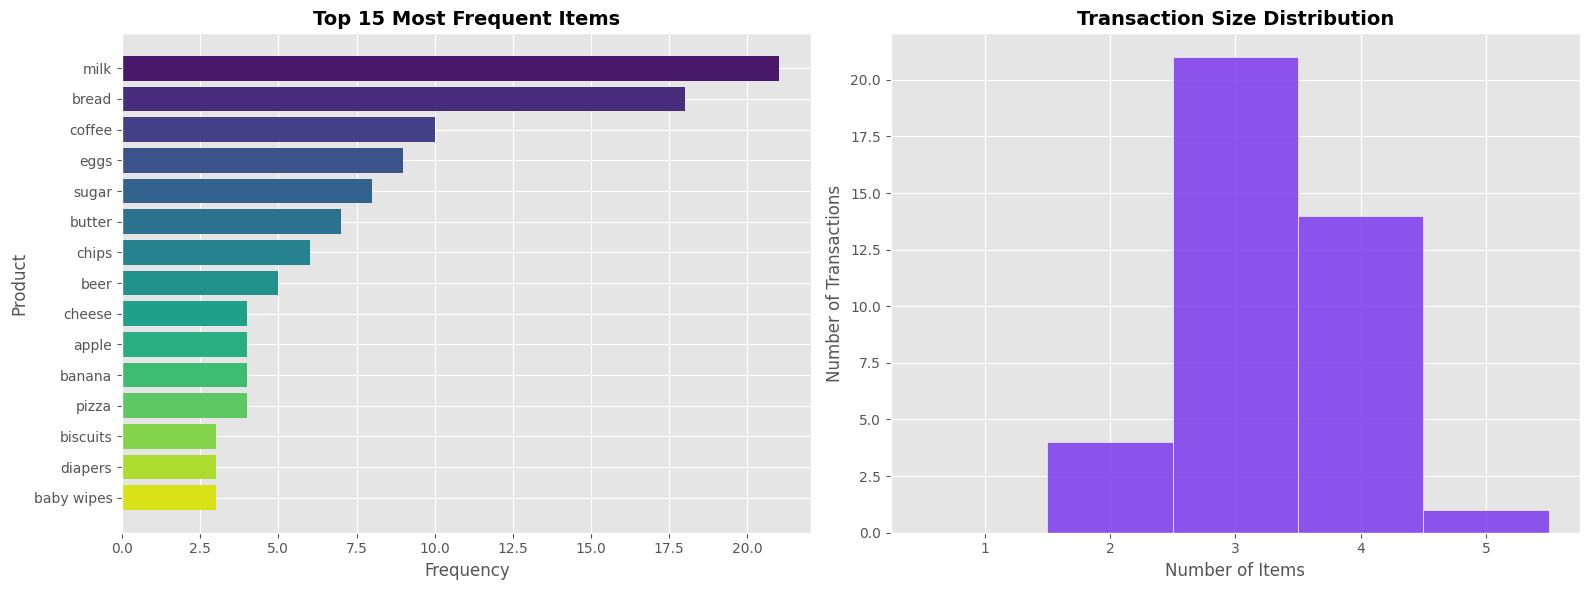

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_items = item_freq_df.head(15)
axes[0].barh(top_items["Item"], top_items["Frequency"], color=sns.color_palette("viridis", 15))
axes[0].set_xlabel("Frequency", fontsize=12)
axes[0].set_ylabel("Product", fontsize=12)
axes[0].set_title("Top 15 Most Frequent Items", fontsize=14, fontweight="bold")
axes[0].invert_yaxis()

basket_sizes = [len(t) for t in cleaned_transactions]
axes[1].hist(basket_sizes, bins=range(1, max(basket_sizes) + 2),
             color="#7c3aed", edgecolor="white", alpha=0.85, align="left")
axes[1].set_xlabel("Number of Items", fontsize=12)
axes[1].set_ylabel("Number of Transactions", fontsize=12)
axes[1].set_title("Transaction Size Distribution", fontsize=14, fontweight="bold")
axes[1].set_xticks(range(1, max(basket_sizes) + 1))
plt.tight_layout()
plt.show()

## Step 4: Transaction Encoding (One-Hot)

The Apriori algorithm requires a **binary matrix** where each row is a transaction and each column is a product.

In [7]:
te = TransactionEncoder()
te_array = te.fit(cleaned_transactions).transform(cleaned_transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f"Encoded matrix shape: {df_encoded.shape}")
df_encoded.head()

Encoded matrix shape: (40, 28)


,apple,baby wipes,bacon,banana,beer,biscuits,bread,butter,cereals,cheese,...,juice,milk,orange,pizza,popcorn,salsa,soda,sugar,tea,yogurt
0,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,True,True,False,False,...,False,True,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,True,True,False,True,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,...,False,True,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


### Co-occurrence Heatmap

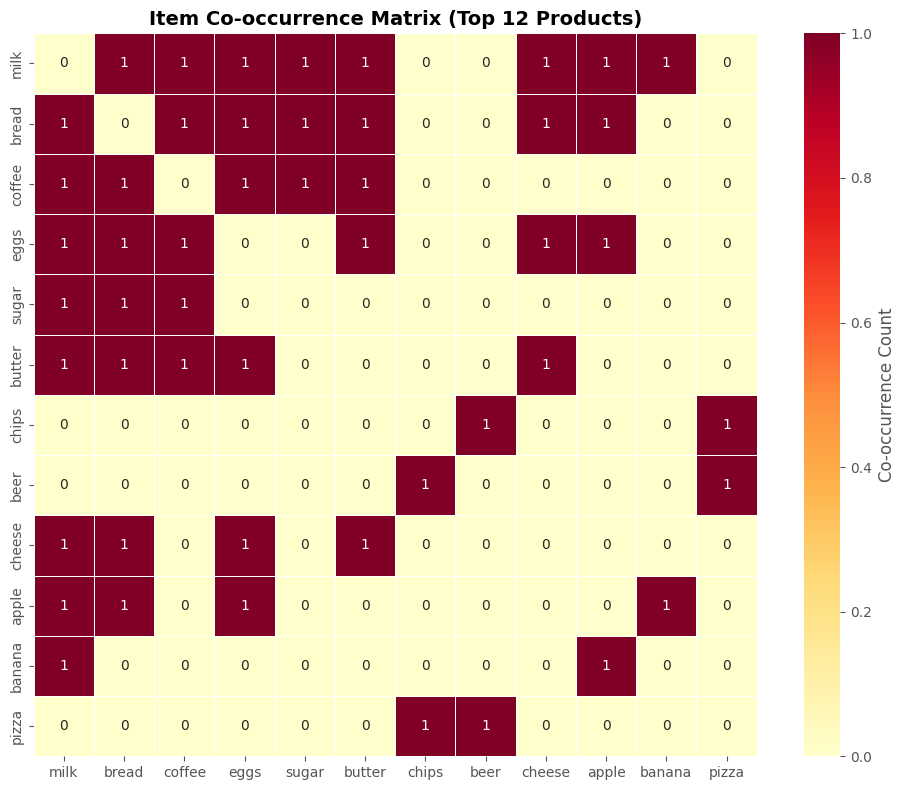

In [8]:
co_occurrence = df_encoded.T.dot(df_encoded)
np.fill_diagonal(co_occurrence.values, 0)

top_12_items = item_freq_df.head(12)["Item"].tolist()
co_top = co_occurrence.loc[top_12_items, top_12_items]

plt.figure(figsize=(10, 8))
sns.heatmap(co_top, annot=True, fmt="d", cmap="YlOrRd",
            linewidths=0.5, square=True, cbar_kws={"label": "Co-occurrence Count"})
plt.title("Item Co-occurrence Matrix (Top 12 Products)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Step 5: Frequent Itemset Mining (Apriori Algorithm)

The **Apriori algorithm** discovers item combinations that appear together frequently.

**How it works:**
1. Start with individual items meeting minimum support
2. Combine into pairs, triples, etc.
3. Prune itemsets below the support threshold
4. **Apriori property**: if an itemset is infrequent, all its supersets are too

In [9]:
MIN_SUPPORT = 0.10

print(f"Min Support: {MIN_SUPPORT} ({MIN_SUPPORT*100:.0f}%)")
print(f"Itemset must appear in at least {int(MIN_SUPPORT * len(cleaned_transactions))} of {len(cleaned_transactions)} transactions\n")

frequent_itemsets = apriori(df_encoded, min_support=MIN_SUPPORT, use_colnames=True, max_len=4)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)

print(f"Total Frequent Itemsets: {len(frequent_itemsets)}\n")
frequent_itemsets.head(20)

Min Support: 0.1 (10%)
Itemset must appear in at least 4 of 40 transactions

Total Frequent Itemsets: 24



,support,itemsets,length
9,0.525,(milk),1
3,0.450,(bread),1
15,0.325,"(milk, bread)",2
7,0.250,(coffee),1
8,0.225,(eggs),1
11,0.200,(sugar),1
4,0.175,(butter),1
14,0.175,"(bread, eggs)",2
18,0.175,"(sugar, coffee)",2
13,0.175,"(bread, butter)",2


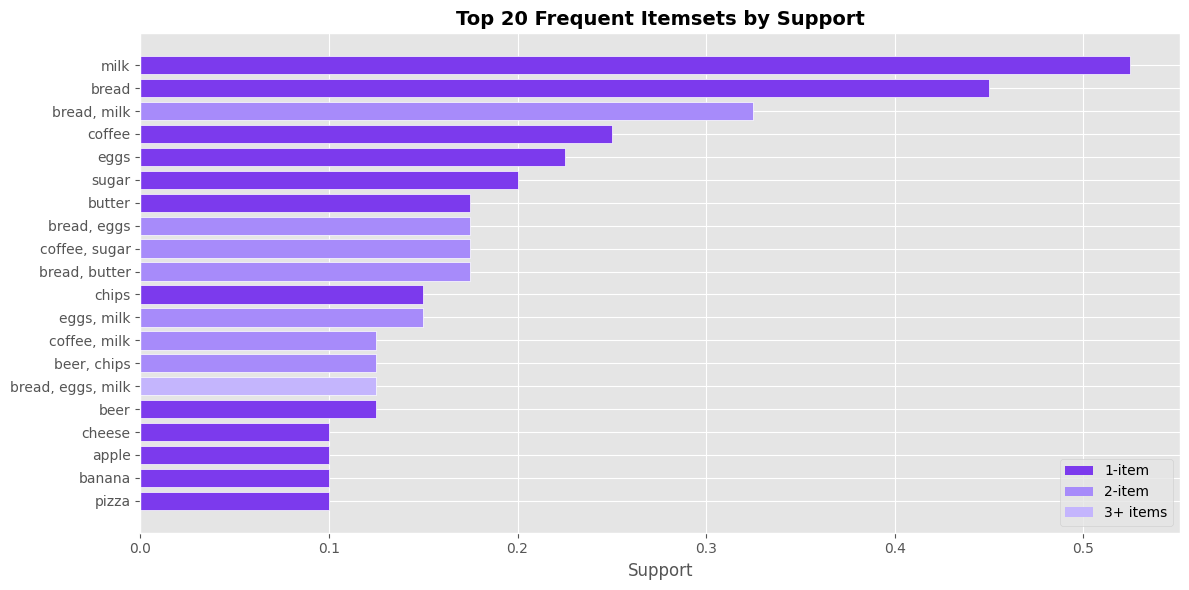

In [10]:
top_fi = frequent_itemsets.head(20).copy()
top_fi["itemsets_str"] = top_fi["itemsets"].apply(lambda x: ", ".join(sorted(x)))

plt.figure(figsize=(12, 6))
colors = ["#7c3aed" if l == 1 else "#a78bfa" if l == 2 else "#c4b5fd" for l in top_fi["length"]]
plt.barh(top_fi["itemsets_str"], top_fi["support"], color=colors, edgecolor="white")
plt.xlabel("Support", fontsize=12)
plt.title("Top 20 Frequent Itemsets by Support", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()

legend_elements = [Patch(facecolor="#7c3aed", label="1-item"), Patch(facecolor="#a78bfa", label="2-item"), Patch(facecolor="#c4b5fd", label="3+ items")]
plt.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

## Step 6: Association Rule Generation

| Metric | Meaning |
|--------|---------|
| **Support** | How often X and Y appear together |
| **Confidence** | Probability of buying Y given X |
| **Lift** | How much more likely Y is when X is present vs random |

In [11]:
MIN_CONFIDENCE = 0.3

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=MIN_CONFIDENCE)
rules = rules.sort_values("lift", ascending=False)

print(f"Min Confidence: {MIN_CONFIDENCE} ({MIN_CONFIDENCE*100:.0f}%)")
print(f"Total Rules: {len(rules)}\n")

rules_display = rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
rules_display["antecedents"] = rules_display["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules_display["consequents"] = rules_display["consequents"].apply(lambda x: ", ".join(sorted(x)))
rules_display.columns = ["If Customer Buys", "Then Also Buys", "Support", "Confidence", "Lift"]
rules_display.head(20)

Min Confidence: 0.3 (30%)
Total Rules: 27



,If Customer Buys,Then Also Buys,Support,Confidence,Lift
10,chips,beer,0.125,0.833333,6.666667
11,beer,chips,0.125,1.000000,6.666667
25,sugar,"coffee, milk",0.100,0.500000,4.000000
22,"milk, sugar",coffee,0.100,1.000000,4.000000
26,coffee,"milk, sugar",0.100,0.400000,4.000000
24,"coffee, milk",sugar,0.100,0.800000,4.000000
4,sugar,coffee,0.175,0.875000,3.500000
5,coffee,sugar,0.175,0.700000,3.500000
7,butter,bread,0.175,1.000000,2.222222
19,"butter, milk",bread,0.100,1.000000,2.222222


## Step 7: Visualization of Results

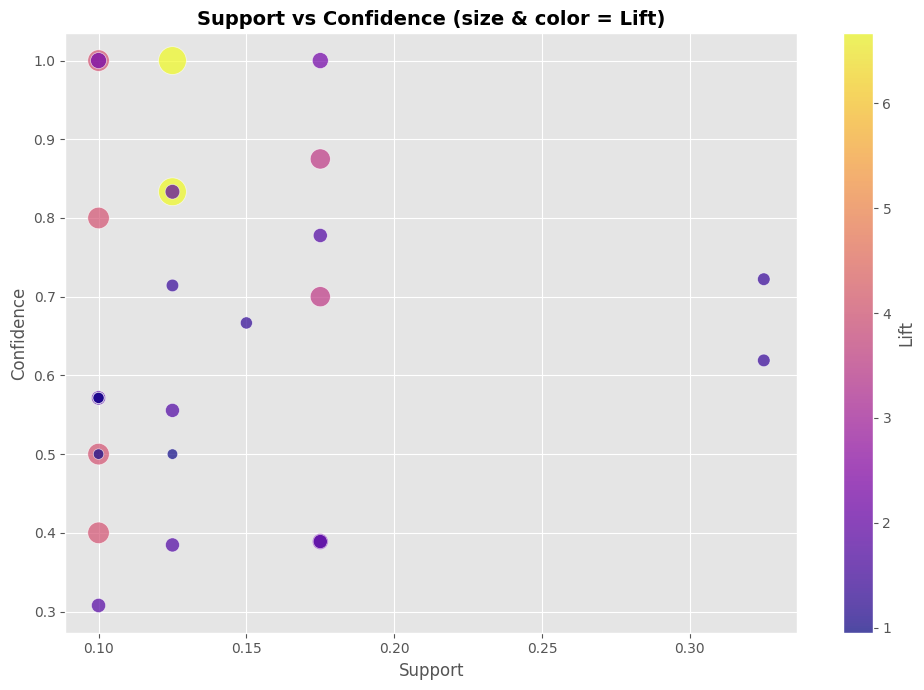

In [12]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(rules["support"], rules["confidence"], c=rules["lift"], cmap="plasma",
                      s=rules["lift"] * 60, alpha=0.7, edgecolors="white", linewidths=0.5)
plt.colorbar(scatter, label="Lift")
plt.xlabel("Support", fontsize=12)
plt.ylabel("Confidence", fontsize=12)
plt.title("Support vs Confidence (size & color = Lift)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

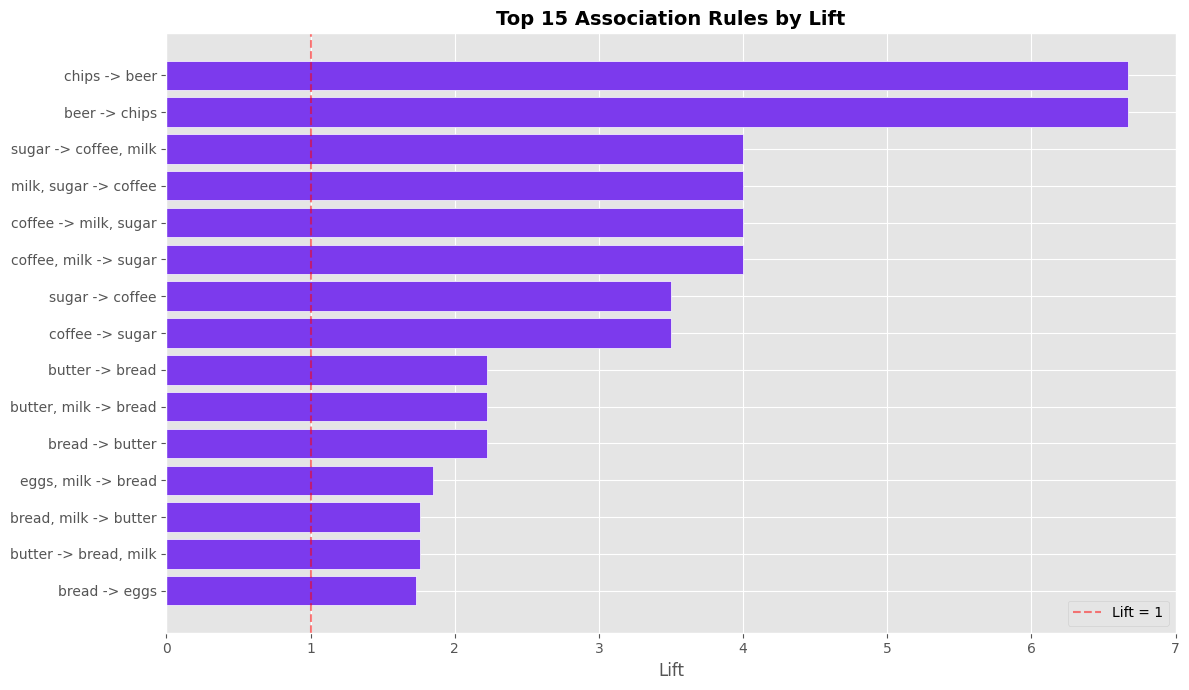

In [13]:
top_rules = rules.head(15).copy()
top_rules["rule"] = top_rules.apply(
    lambda r: ", ".join(sorted(r["antecedents"])) + " -> " + ", ".join(sorted(r["consequents"])), axis=1
)

plt.figure(figsize=(12, 7))
plt.barh(top_rules["rule"], top_rules["lift"], color="#7c3aed", edgecolor="white")
plt.axvline(x=1, color="red", linestyle="--", alpha=0.5, label="Lift = 1")
plt.xlabel("Lift", fontsize=12)
plt.title("Top 15 Association Rules by Lift", fontsize=14, fontweight="bold")
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Step 8: Model Evaluation

In [14]:
print("Rule Quality Summary")
print(f"Total rules        : {len(rules)}")
print(f"Avg Confidence     : {rules['confidence'].mean():.3f}")
print(f"Avg Lift           : {rules['lift'].mean():.3f}")
print(f"Max Lift           : {rules['lift'].max():.3f}")
print(f"Rules with Lift > 1: {(rules['lift'] > 1).sum()} ({(rules['lift'] > 1).mean()*100:.1f}%)")

strong_rules = rules[(rules["confidence"] >= 0.5) & (rules["lift"] >= 1.5)]
print(f"\nStrong Rules (confidence >= 50%, lift >= 1.5): {len(strong_rules)}\n")

for _, row in strong_rules.iterrows():
    ant = ", ".join(sorted(row["antecedents"]))
    con = ", ".join(sorted(row["consequents"]))
    print(f"  {ant} -> {con}  |  conf: {row['confidence']:.1%}  |  lift: {row['lift']:.2f}")

Rule Quality Summary
Total rules        : 27
Avg Confidence     : 0.658
Avg Lift           : 2.437
Max Lift           : 6.667
Rules with Lift > 1: 25 (92.6%)

Strong Rules (confidence >= 50%, lift >= 1.5): 13

  chips -> beer  |  conf: 83.3%  |  lift: 6.67
  beer -> chips  |  conf: 100.0%  |  lift: 6.67
  sugar -> coffee, milk  |  conf: 50.0%  |  lift: 4.00
  milk, sugar -> coffee  |  conf: 100.0%  |  lift: 4.00
  coffee, milk -> sugar  |  conf: 80.0%  |  lift: 4.00
  sugar -> coffee  |  conf: 87.5%  |  lift: 3.50
  coffee -> sugar  |  conf: 70.0%  |  lift: 3.50
  butter -> bread  |  conf: 100.0%  |  lift: 2.22
  butter, milk -> bread  |  conf: 100.0%  |  lift: 2.22
  eggs, milk -> bread  |  conf: 83.3%  |  lift: 1.85
  butter -> bread, milk  |  conf: 57.1%  |  lift: 1.76
  eggs -> bread  |  conf: 77.8%  |  lift: 1.73
  eggs -> bread, milk  |  conf: 55.6%  |  lift: 1.71


## Step 9: Practical Recommendation Demo

In [15]:
def recommend_products(cart_items, rules_df, top_n=5):
    cart_set = set(item.lower() for item in cart_items)
    recommendations = {}
    for _, row in rules_df.iterrows():
        antecedent = set(row["antecedents"])
        consequent = set(row["consequents"])
        if antecedent.issubset(cart_set):
            new_items = consequent - cart_set
            for item in new_items:
                if item not in recommendations or recommendations[item] < row["lift"]:
                    recommendations[item] = row["lift"]
    return sorted(recommendations.items(), key=lambda x: x[1], reverse=True)[:top_n]

test_carts = [["milk"], ["bread", "butter"], ["coffee", "sugar"], ["eggs", "bacon"], ["pizza", "beer"], ["diapers"]]

for cart in test_carts:
    recs = recommend_products(cart, rules)
    print(f"Cart: {cart}")
    if recs:
        for item, lift in recs:
            print(f"   -> {item:15s} (lift: {lift:.2f})")
    else:
        print("   -> No strong recommendations")
    print()

Cart: ['milk']
   -> bread           (lift: 1.38)

Cart: ['bread', 'butter']
   -> milk            (lift: 1.76)
   -> eggs            (lift: 1.73)

Cart: ['coffee', 'sugar']
   -> milk            (lift: 4.00)

Cart: ['eggs', 'bacon']
   -> bread           (lift: 1.73)
   -> milk            (lift: 1.71)

Cart: ['pizza', 'beer']
   -> chips           (lift: 6.67)

Cart: ['diapers']
   -> No strong recommendations



## Step 10: Conclusions

### Key Findings
1. `milk` and `bread` are the most frequently purchased items
2. `beer -> chips` has the highest lift (strongest association)
3. `coffee` and `sugar` are frequently bought together
4. Most rules have lift > 1, indicating genuine positive associations

### Business Applications
| Application | How |
|-------------|-----|
| **Product Placement** | Place associated items nearby in store |
| **Bundle Promotions** | Create discounts on frequently co-purchased items |
| **Cross-selling** | Recommend complementary products online |
| **Inventory Management** | Stock associated items together |

### Integration with Web App
This exact algorithm (Apriori) is implemented in the **Market Basket Analyzer PWA** using Node.js. Users upload sales data via CSV or manual entry, and the app provides real-time product recommendations using the same association rule mining approach demonstrated here.